# KAN Cross-File Testing
### Testing our trained KAN on the other APD detector settings

This notebook takes the KAN trained on **MOESM3** (in the main notebook) and tests it on the other two APD files, **MOESM4** and **MOESM5**.

**Important physics caveat.** The three APD files are *three different detector configurations* from the paper's Fig. 2 — different LO strength $|\alpha_{LO}|^2$ and mode overlap $\mathcal{M}$. So the same probe $(|\alpha|^2,\theta)$ gives a *different* $p(\text{1-click})$ in each file. Our KAN learned **one** detector's response.

We run two experiments:

1. **Cross-file generalization** — apply the MOESM3-trained KAN directly to files 4 & 5. We *expect* mismatch where the settings differ; the size of that mismatch is the result.
2. **Per-file retrain** — train a fresh KAN on each file separately, confirming the *method* works on all three (a robustness check, not a generalization claim).

---
## 0 · Setup


In [1]:
# !pip install pykan torch xlrd scipy scikit-learn matplotlib
import numpy as np, torch, time, os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from kan import KAN
torch.set_default_dtype(torch.float64)
np.random.seed(0); torch.manual_seed(0)
print("imports OK")

imports OK


In [2]:
# ---- paths ----
DATA_DIR = "data"   # <-- folder holding the .xls files
FILES = {
    "MOESM3": f"{DATA_DIR}/41566_2012_BFnphoton2012107_MOESM3_ESM.xls",  # training detector
    "MOESM4": f"{DATA_DIR}/41566_2012_BFnphoton2012107_MOESM4_ESM.xls",
    "MOESM5": f"{DATA_DIR}/41566_2012_BFnphoton2012107_MOESM5_ESM.xls",
}
CKPT = "./kan_tuned_ckpt"   # checkpoint from main notebook; if missing we retrain below

## 1 · Helpers: load a file, build (input, label)

Same loader and label definition as the main notebook:
$\;X=(|\alpha|^2,\theta)\;$, $\;y=p_{\text{1-click}}=\#1\text{-click}/(\#0\text{-click}+\#1\text{-click})$.


In [3]:
import xlrd

def load_file(path):
    sh = xlrd.open_workbook(path).sheet_by_index(0)
    rows = np.array([sh.row_values(r) for r in range(1, sh.nrows)])
    a2, theta, c0, c1 = rows[:,0], rows[:,1], rows[:,2], rows[:,3]
    X = np.column_stack([a2, theta])
    y = c1 / (c0 + c1)
    return X, y

for name, p in FILES.items():
    X, y = load_file(p)
    print("%s: %d rows | |a|^2 %.3f..%.1f | p1 %.3f..%.3f"
          % (name, len(X), X[:,0].min(), X[:,0].max(), y.min(), y.max()))

MOESM3: 4400 rows | |a|^2 0.044..56.2 | p1 0.006..0.997
MOESM4: 3720 rows | |a|^2 0.178..38.5 | p1 0.001..0.997
MOESM5: 4760 rows | |a|^2 0.057..166.9 | p1 0.430..0.996


## 2 · The input transform

The KAN was trained on `log1p(|α|²)` then normalised to $[-1,1]$ using **MOESM3's** train statistics. To test on other files we MUST reuse those *same* statistics (the network only understands inputs on the scale it was trained on). So we fit the normaliser on MOESM3 and apply it everywhere.


In [4]:
prep = lambda X: np.column_stack([np.log1p(X[:,0]), X[:,1]])

# normaliser fit on MOESM3 (the training file)
X3, y3 = load_file(FILES["MOESM3"])
X3tr, X3te, y3tr, y3te = train_test_split(X3, y3, test_size=0.20, random_state=42)
MN, MX = prep(X3tr).min(0), prep(X3tr).max(0)
norm = lambda X: 2*(prep(X) - MN)/(MX - MN) - 1

def predict(model, X):
    with torch.no_grad():
        return torch.sigmoid(model(torch.tensor(norm(X)))).numpy().ravel()
def rms(model, X, y):
    return float(np.sqrt(np.mean((predict(model, X) - y)**2)))
print("normaliser fit on MOESM3 train stats")

normaliser fit on MOESM3 train stats


## 3 · Get the trained KAN — load checkpoint, or retrain

If the MOESM3 checkpoint is present we load it. Otherwise we retrain it from scratch (identical to the main notebook: `[2,3,1]`, 150 steps at grid 5, then refine to grid 10). Either way `model` ends up being the MOESM3-trained KAN.


In [5]:
def sig_mse(pred, target):
    return torch.mean((torch.sigmoid(pred) - target)**2)

def train_kan_on(Xtr, ytr, Xte, yte):
    ds = {"train_input": torch.tensor(norm(Xtr)), "train_label": torch.tensor(ytr.reshape(-1,1)),
          "test_input":  torch.tensor(norm(Xte)), "test_label":  torch.tensor(yte.reshape(-1,1))}
    m = KAN(width=[2,3,1], grid=5, k=3, seed=0)
    m.fit(ds, opt="LBFGS", steps=150, loss_fn=sig_mse)
    m = m.refine(10)
    m.fit(ds, opt="LBFGS", steps=80, loss_fn=sig_mse)
    return m

loaded = False
if os.path.exists(CKPT + "_state") or os.path.exists(CKPT + "_config.yml"):
    try:
        model = KAN.loadckpt(CKPT)
        loaded = True
        print("loaded checkpoint:", CKPT)
    except Exception as e:
        print("checkpoint load failed (%s) -> retraining" % e)

if not loaded:
    print("retraining KAN on MOESM3 (~2-3 min)...")
    model = train_kan_on(X3tr, y3tr, X3te, y3te)

print("MOESM3 test RMS (sanity): %.5f" % rms(model, X3te, y3te))

retraining KAN on MOESM3 (~2-3 min)...
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 7.87e-03 | test_loss: 7.80e-03 | reg: 3.43e+01 | : 100%|█| 150/150 [00:13<00:00, 10.82


saving model version 0.1
saving model version 0.2


| train_loss: 6.86e-03 | test_loss: 7.06e-03 | reg: 3.45e+01 | : 100%|█| 80/80 [00:08<00:00,  9.49it

saving model version 0.3
MOESM3 test RMS (sanity): 0.00706


## 4 · Experiment 1 — Cross-file generalization

Apply the **MOESM3-trained** KAN to all of files 4 and 5 (every row as test data). Because these are different detector settings, expect higher error than the ~0.007 MOESM3 baseline. The *amount* tells us how far the learned response transfers.


In [6]:
print("Cross-file: MOESM3-trained KAN applied to each file\n")
print(f"{'file':8} {'rows':>6} {'RMS':>9} {'max|err|':>9}")
xfile = {}
for name, p in FILES.items():
    X, y = load_file(p)
    pred = predict(model, X)
    r = float(np.sqrt(np.mean((pred - y)**2)))
    xfile[name] = (X, y, pred, r)
    tag = "  <- trained here" if name == "MOESM3" else ""
    print(f"{name:8} {len(X):6d} {r:9.5f} {np.max(np.abs(pred-y)):9.5f}{tag}")

Cross-file: MOESM3-trained KAN applied to each file

file       rows       RMS  max|err|
MOESM3     4400   0.00690   0.05871  <- trained here
MOESM4     3720   0.22360   0.43187
MOESM5     4760   0.21149   0.98550


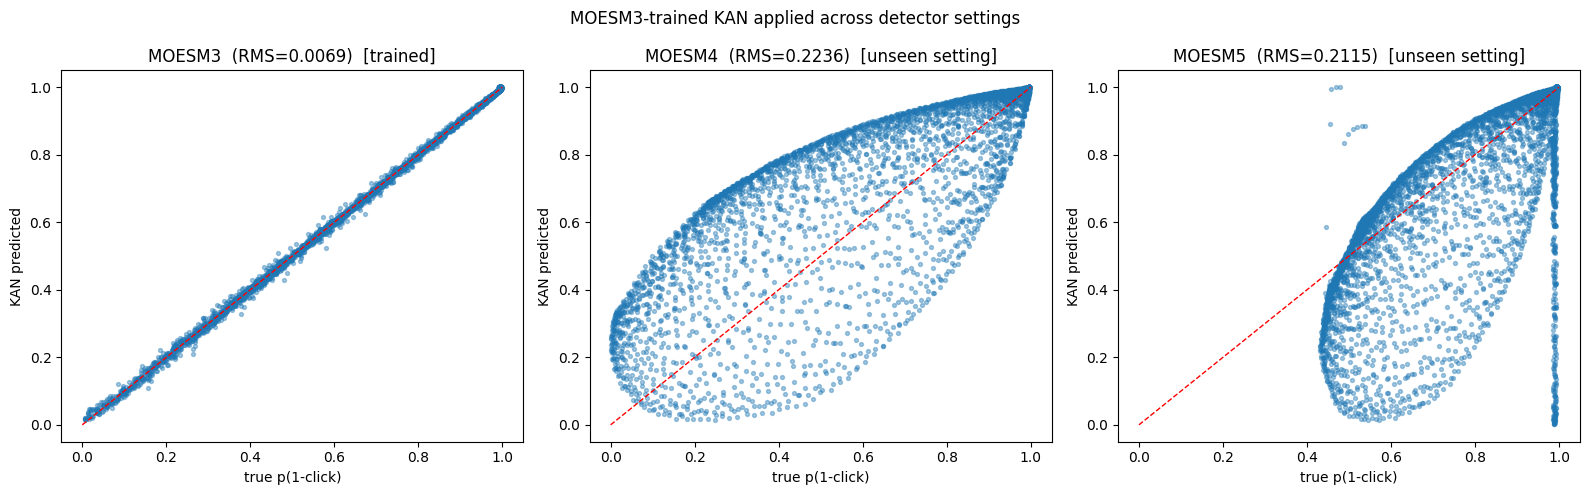

In [7]:
# visualise predicted vs true for each file
fig, ax = plt.subplots(1, 3, figsize=(16,5))
for i, name in enumerate(FILES):
    X, y, pred, r = xfile[name]
    ax[i].scatter(y, pred, s=8, alpha=.4)
    ax[i].plot([0,1],[0,1],'r--',lw=1)
    ax[i].set_xlabel("true p(1-click)"); ax[i].set_ylabel("KAN predicted")
    ax[i].set_title(f"{name}  (RMS={r:.4f})" + ("  [trained]" if name=="MOESM3" else "  [unseen setting]"))
plt.suptitle("MOESM3-trained KAN applied across detector settings")
plt.tight_layout(); plt.show()

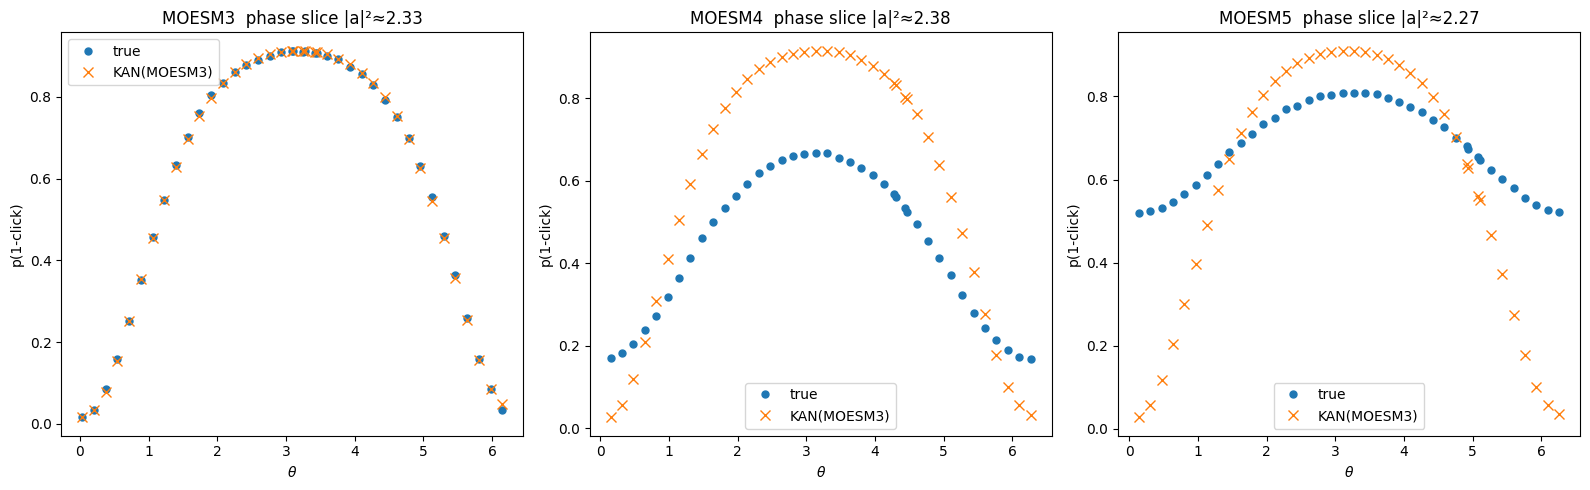

In [8]:
# phase-slice view: where does the cross-file prediction break down?
fig, ax = plt.subplots(1, 3, figsize=(16,5))
for i, name in enumerate(FILES):
    X, y, pred, r = xfile[name]
    a2 = X[:,0]; tgt = a2[np.argmin(np.abs(a2-2.33))]
    m = np.isclose(a2, tgt, atol=2e-2); o = np.argsort(X[m,1])
    ax[i].plot(X[m,1][o], y[m][o], 'o', label="true", ms=5)
    ax[i].plot(X[m,1][o], pred[m][o], 'x', label="KAN(MOESM3)", ms=7)
    ax[i].set_xlabel(r"$\theta$"); ax[i].set_ylabel("p(1-click)")
    ax[i].set_title(f"{name}  phase slice |a|²≈{tgt:.2f}"); ax[i].legend()
plt.tight_layout(); plt.show()

## 5 · Experiment 2 — Per-file retrain (method robustness)

Now train a *fresh* KAN on each file's own 80/20 split. If each retrained KAN fits its own file well (~0.007-ish), that confirms the **method** works on all three settings — independent of whether one transfers to another.


In [9]:
print(f"{'file':8} {'train RMS':>10} {'test RMS':>10}")
perfile = {}
for name, p in FILES.items():
    X, y = load_file(p)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20, random_state=42)
    t = time.time()
    m = train_kan_on(Xtr, ytr, Xte, yte)
    perfile[name] = (m, Xte, yte, rms(m, Xte, yte))
    print(f"{name:8} {rms(m,Xtr,ytr):10.5f} {rms(m,Xte,yte):10.5f}   [{time.time()-t:.0f}s]")

file      train RMS   test RMS
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 7.87e-03 | test_loss: 7.80e-03 | reg: 3.43e+01 | : 100%|█| 150/150 [00:13<00:00, 11.08


saving model version 0.1
saving model version 0.2


| train_loss: 6.86e-03 | test_loss: 7.06e-03 | reg: 3.45e+01 | : 100%|█| 80/80 [00:08<00:00,  9.41it


saving model version 0.3
MOESM3      0.00686    0.00706   [22s]
checkpoint directory created: ./model
saving model version 0.0


...

saving model version 0.3
MOESM4      0.00310    0.00335   [20s]
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.89e-03 | test_loss: 2.06e-03 | reg: 1.46e+01 | : 100%|█| 150/150 [00:13<00:00, 10.80


saving model version 0.1
saving model version 0.2


| train_loss: 1.72e-03 | test_loss: 1.83e-03 | reg: 1.48e+01 | : 100%|█| 80/80 [00:08<00:00,  9.20it

saving model version 0.3
MOESM5      0.00172    0.00183   [23s]


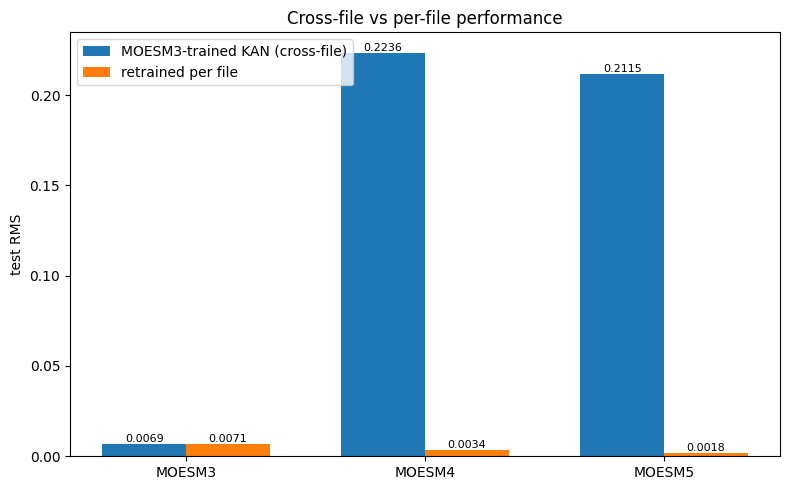

In [10]:
# compare cross-file vs per-file RMS side by side
names = list(FILES)
xf = [xfile[n][3] for n in names]
pf = [perfile[n][3] for n in names]
xx = np.arange(len(names)); w = 0.35
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(xx - w/2, xf, w, label="MOESM3-trained KAN (cross-file)")
ax.bar(xx + w/2, pf, w, label="retrained per file")
ax.set_xticks(xx); ax.set_xticklabels(names); ax.set_ylabel("test RMS")
ax.set_title("Cross-file vs per-file performance"); ax.legend()
for i,(a,b) in enumerate(zip(xf,pf)):
    ax.text(i-w/2, a, f"{a:.4f}", ha="center", va="bottom", fontsize=8)
    ax.text(i+w/2, b, f"{b:.4f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

## 6 · Reading the results

- **MOESM3 bars equal** (cross-file == per-file) — it's the training file, sanity check.
- **MOESM4 / MOESM5 cross-file RMS high, per-file RMS low** → the *method* generalises (a KAN can learn any of these detectors), but a KAN trained on *one* setting does **not** transfer to another — because they are physically different detectors. Expected, and a clean result to state.
- **If cross-file RMS were also low** → the settings happen to produce similar responses in the probed region (e.g. MOESM4 is close to MOESM3 in $|\alpha_{LO}|^2$).

This is the cross-file generalisation experiment made concrete for the detector-response setting.

### Notes
- The normaliser is fixed to MOESM3 stats for Experiment 1 (correct — the model only understands that scale). Experiment 2 *also* reuses it for consistency; if a file's $|\alpha|^2$ range far exceeds MOESM3's, its normalised inputs land outside $[-1,1]$ and the retrained KAN there is mildly extrapolating. MOESM5 reaches $|\alpha|^2\approx167$ vs MOESM3's $\approx56$, so watch its per-file number.
- For a fully independent per-file study you'd refit the normaliser per file; kept shared here so Experiment 1 and 2 are directly comparable.
